<a href="https://colab.research.google.com/github/imend35/Customer-Churn-Prediction-with-Machine-Learning/blob/main/churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Müşteri Sadakat İzleme Projesi

#Veri Yükleme ve Keşif

Bu kod bloğu, bir veri bilimci veya analistinin bir veri setini ilk kez eline aldığında yaptığı Keşifçi Veri Analizi (EDA - Exploratory Data Analysis) sürecinin temel adımlarını içeriyor.

İşte her satırın ne işe yaradığına dair açıklamalar:

In [2]:
import pandas as pd  # Veri manipülasyonu ve analizi için en temel kütüphane olan Pandas'ı projeye dahil ettim.

# Veri setini yükleme
# Proje klasöründeki "telco_churn.csv" dosyasını okur ve bir DataFrame (tablo) yapısına dönüştürdüm.
df = pd.read_csv("telco_churn.csv")

# İlk 5 satır
print("İlk 5 satır:")
# Veri setinin en üstteki 5 satırını ekrana yazdırır. Verinin içeriğine hızlı bir göz atmak istiyorum.
print(df.head())

# Veri boyutu
print("\nVeri boyutu:", df.shape)
# Verinin toplam kaç satır (gözlem) ve kaç sütundan (özellik) oluştuğunu (satır, sütun) şeklinde inceledim.

# Sütun bilgileri
print("\nSütun tipleri:")
# Sütun isimlerini, içerdikleri veri tiplerini (sayı, metin vb.) ve boş olmayan hücre sayılarını inceledim.
print(df.info())

# Eksik değer kontrolü
print("\nEksik değer sayıları:")
# Veri setindeki her bir sütunda toplam kaç adet "boş" veya "eksik" (NaN) hücre olduğunu hesapladım.
print(df.isnull().sum())

# Churn dağılımı
print("\nChurn dağılımı:")
# Hedef değişkenimiz olan "Churn" sütunundaki sınıfların (Giden: Yes / Kalan: No) sayısal adetlerini bulmak istiyorum.
print(df["Churn"].value_counts())

# Yüzdesel dağılım
print("\nChurn yüzdeleri:")
# Sınıfların adetlerini değil, veri setinin genelindeki yüzdesel oranlarını (örneğin: %26 churn) hesapladım.
print(df["Churn"].value_counts(normalize=True) * 100)

İlk 5 satır:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        

#Veri Temizleme

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Veri setini oku
df = pd.read_csv("telco_churn.csv")

# customerID işimize yaramaz
df.drop("customerID", axis=1, inplace=True)

# TotalCharges sayısal olmalı
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Eksik değerleri sil
df.dropna(inplace=True)

# Binary kolonları encode et
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]

le = LabelEncoder()
for col in binary_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Hedef ve özellikler
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5625, 30)
X_test shape: (1407, 30)


Veri hazırlığını tamamladım, şimdi işin mutfağına girip ilk modelimi kuruyorum. Lojistik Regresyon, bu tür sınıflandırma problemlerinde başlangıç için en sağlam tercihlerden biri. İşte bu adımlarda neler yaptığım:

#Logistic Regression Model Kurulumu

In [5]:
from sklearn.linear_model import LogisticRegression # Sınıflandırma yapabilmek için Lojistik Regresyon kütüphanesini projeme dahil ettim.

# Modeli oluştur
# Model nesnemi oluşturdum. 'max_iter=1000' parametresini ekledim ki model karmaşık verilerde çözüme ulaşana kadar yeterli denemeyi yapabilsin.
model = LogisticRegression(max_iter=1000)

# Eğit
# Hazırladığım eğitim verilerini (X_train) ve doğru cevapları (y_train) modele vererek öğrenme sürecini başlattım.
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Modeli eğittikten sonra şimdi sıra en can alıcı noktaya, yani tahmin aşamasına geldi. Modelim artık görmediği veriler hakkında yorum yapabiliyor. İşte bu satırlarda yaptıklarım:

#Tahmin Aşaması

In [6]:
# Tahmin yap
# Test verilerimi (X_test) modele verdim ve her bir müşterinin "kalacak mı gidecek mi" (0 veya 1) kararını tahmin etmesini sağladım.
y_pred = model.predict(X_test)

# Olasılık tahmini
# Modelin sadece 0-1 demesi yetmez, ne kadar emin olduğunu da bilmek istedim. Bu yüzden her tahminin olasılık değerini aldım ve pozitif sınıfa (churn) odaklandım.
y_prob = model.predict_proba(X_test)[:, 1]

# Tahmin sonuçlarını kontrol ediyorum
# İlk 10 müşterinin sınıf tahminlerini (0 veya 1) ekrana bastım.
print("İlk 10 tahmin:", y_pred[:10])
# Bu tahminlerin arkasındaki olasılıkları (örn: 0.85 gibi) görerek modelin güven düzeyini inceledim.
print("İlk 10 olasılık:", y_prob[:10])

İlk 10 tahmin: [0 1 0 0 0 0 0 0 1 0]
İlk 10 olasılık: [0.01808017 0.58482183 0.00457711 0.20300762 0.1039759  0.47645061
 0.02554757 0.16565718 0.66634811 0.01568117]


Tahminlerimi yaptım, şimdi dürüst olma vakti! Modelimin ne kadar başarılı olduğunu görmek için performans ölçümü yapıyorum. İşte sonuçları analiz ederken kullandığım yöntemler:

#Model Değerlendirme

In [7]:
# Başarı ölçümü için gerekli metrik araçlarını kütüphaneden çağırdım.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy (Doğruluk)
# Modelimin genel olarak ne kadar başarılı olduğunu görmek için doğru tahminlerin toplam tahmine oranını hesapladım.
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detaylı rapor
# Sadece genel doğruluk yetmez; her iki sınıf (giden ve kalan) için kesinlik, duyarlılık ve F1-skoru gibi detaylara bakarak modelin zayıf yanlarını inceledim.
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix (Hata Matrisi)
# Modelim kaç kişiyi giderken kalacak sandı, kaç kişiyi kalacakken gidecek sandı? Bu matrisle hatalarımın tam olarak nerede yoğunlaştığını gördüm.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8017057569296375

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix:
[[916 117]
 [162 212]]


Hangi özellikler müşterinin gitmesine neden oluyor, hangileri sadakati artırıyor? İşte katsayı analiziyle bu soruları cevapladığım kısım:

#Özellik Önemi

In [8]:
import pandas as pd # Verileri tablo halinde düzenleyebilmek için Pandas kullanıyorum.

# Modelin her bir bağımsız değişkene (X) verdiği katsayıları ve sütun isimlerini bir araya getirerek bir tablo oluşturdum.
coefficients = pd.DataFrame({
    "Feature": X.columns,      # Modelde kullandığım özelliklerin isimleri
    "Coefficient": model.coef_[0] # Modelin bu özelliklere verdiği ağırlık puanları
})

# Katsayıları en yüksekten en düşüğe doğru sıraladım ki etkisi en güçlü olanları en üstte görebileyim.
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

# Sonuç etkileyen en önemli (pozitif yönde churn riskini artıran) ilk 10 özelliği ekrana basarak inceledim.
print(coefficients.head(10))

                                  Feature  Coefficient
11            InternetService_Fiber optic     0.675986
28         PaymentMethod_Electronic check     0.388251
6                        PaperlessBilling     0.293599
10                      MultipleLines_Yes     0.276168
9          MultipleLines_No phone service     0.252543
22                        StreamingTV_Yes     0.194470
1                           SeniorCitizen     0.193429
24                    StreamingMovies_Yes     0.165789
29             PaymentMethod_Mailed check     0.071300
27  PaymentMethod_Credit card (automatic)     0.044585


Standart modelin kararlarını biraz daha "tetikte" olacak şekilde modifiye etmeye karar verdim. Şirket için bir müşteriyi kaybetmenin maliyeti, ona fazladan bir kampanya sunmanın maliyetinden çok daha yüksek olabilir. İşte bu yüzden eşik değerini esnettiğim o bölüm:

##Threshold değiştirerek modeli daha akıllı yapabiliriz

In [9]:
import numpy as np # Sayısal dönüşümler ve dizi işlemleri için Numpy kütüphanesinden yararlandım.

# Varsayılan 0.5 olan eşik (threshold) değerini 0.3'e çektim.
# Yani artık bir müşterinin gitme olasılığı %30 bile olsa, onu "riskli" olarak işaretliyorum.
threshold = 0.3

# Hesapladığım olasılıkları (y_prob) bu yeni eşik değeriyle kıyasladım ve sonuçları tekrar 0-1 formatına dönüştürdüm.
y_pred_custom = (y_prob > threshold).astype(int)

# Yeni stratejimin hata matrisine bakıyorum.
# Bu hamlemle kaç tane gerçek "churn" vakasını daha yakaladığımı (Recall artışı) analiz ettim.
print(confusion_matrix(y_test, y_pred_custom))

[[764 269]
 [ 90 284]]


Lojistik Regresyon'un yanına şimdi de daha güçlü ve yetenekli bir "takım kaptanı" ekliyorum. Tek bir karar ağacı yerine yüzlerce ağacın fikrini alan Random Forest algoritmasını kurarak tahminlerimi daha sağlam bir zemine oturtuyorum. İşte bu aşamada yaptıklarım:

#Random Forest Model Kurulumu

In [10]:
from sklearn.ensemble import RandomForestClassifier # Birden fazla karar ağacını birleştirerek daha güçlü tahminler yapan bu kütüphaneyi dahil ettim.

# Modeli oluşturma
# Rastgele Orman (Random Forest) modelimi özel ayarlarla yapılandırdım:
rf_model = RandomForestClassifier(
    n_estimators=200,    # Modelimin içinde tam 200 adet farklı karar ağacı oluşturulmasını istedim; sayı arttıkça hata payı genellikle azalır.
    max_depth=10,        # Her bir ağacın derinliğini 10 katmanla sınırladım ki modelim veriyi ezberleyip (overfitting) gerçek hayatı kaçırmasın.
    random_state=42,     # Deneyimi her tekrarladığımda aynı sonuçları alabilmek için bu sabit rastgelelik değerini belirledim.
    class_weight="balanced" # Verimdeki azınlıkta kalan churn grubuna modelin daha fazla dikkat etmesini, onları görmezden gelmemesini sağladım.
)

# Eğitme
# Hazırladığım eğitim setini (X_train, y_train) bu ormana teslim ettim ve modelin karmaşık ilişkileri öğrenmesini sağladım.
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

Orman modelim eğitimini tamamladı, şimdi onu gerçek sınavına sokuyorum! Bakalım bu 200 ağaç bir araya gelince müşterilerim hakkında neler söyleyecek? İşte tahminleri aldığım o anlar:

#Tahminler

In [11]:
# Tahminler
# Test setimi (X_test) ormanın içine gönderdim; 200 ağaç oylamasını yaptı ve bana her müşteri için net bir sınıf tahmini (0 veya 1) döndürdü.
y_pred_rf = rf_model.predict(X_test)

# Olasılık tahmini
# Sadece "gider" veya "kalır" demekle yetinmedim. Modelin bu kararı verirken ne kadar emin olduğunu anlamak için 1 (Churn) sınıfına ait olasılık puanlarını çıkardım.
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Sonuçları inceliyorum
# Rastgele Orman modelimin test setindeki ilk 10 müşteri için verdiği kararları ekrana bastım.
print("İlk 10 Random Forest tahmini:", y_pred_rf[:10])
# Bu 10 müşterinin "gitme ihtimalini" yüzde bazında görerek modelin tahmin gücünü gözlemledim.
print("İlk 10 Random Forest olasılığı:", y_prob_rf[:10])

İlk 10 Random Forest tahmini: [0 1 0 0 0 1 0 0 1 0]
İlk 10 Random Forest olasılığı: [0.01529784 0.81501292 0.03171457 0.15323031 0.21746926 0.58762537
 0.04027544 0.21478595 0.75918115 0.01180213]


Rastgele Orman modelimin tahminlerini aldım, şimdi bu "akıllı ormanın" gerçekte ne kadar başarılı olduğunu karneye dökme zamanı. Lojistik Regresyon ile kıyasladığımda aradaki farkı net bir şekilde görebilmek için şu adımları izledim:

#Performans Ölçme

In [12]:
# Başarı metriklerini hesaplayabilmek için gerekli ölçüm araçlarımı çağırdım.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Random Forest Accuracy
# Modelimin genel doğruluk oranına baktım; yani 200 ağacın ortak kararıyla toplamda ne kadarlık bir isabet sağladığımızı hesapladım.
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Random Forest Classification Report
# Sadece genel başarıya bakmak beni yanıltabilir. Bu yüzden 'churn' olan ve olmayan müşteriler bazında kesinlik (precision) ve duyarlılık (recall) gibi detaylı skorları inceledim.
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Random Forest Confusion Matrix
# Hata matrisini ekrana basarak, modelimin hangi noktalarda yanıldığını; örneğin kaç sadık müşteriyi "gidecek" olarak işaretlediğini net bir tablo şeklinde gördüm.
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7704335465529495

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.75      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407


Random Forest Confusion Matrix:
[[805 228]
 [ 95 279]]


Modelimin performansını ölçtükten sonra, bu kararları verirken hangi özelliklere daha çok güvendiğini anlamak istedim. Random Forest'ın en sevdiğim yanlarından biri de tam olarak bu: Hangi verinin daha "belirleyici" olduğunu bana açıkça söyleyebiliyor. İşte bu analizi yaptığım adımlar:

#Feature importance - Özellik Önemi

In [13]:
# Modelin içindeki her bir özelliğin (Feature) önem skorunu ve isimlerini alarak yeni bir tablo oluşturdum.
feature_importance = pd.DataFrame({
    "Feature": X.columns,                      # Veri setindeki sütun başlıklarım
    "Importance": rf_model.feature_importances_ # Modelin bu sütunlara verdiği "önem puanı"
})

# Bu puanları en yüksekten en düşüğe doğru sıraladım; böylece modelin odak noktasını en üste taşıdım.
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Müşteri terkini (Churn) tahmin ederken modelimi en çok etkileyen ilk 10 ana faktörü ekrana bastım.
print(feature_importance.head(10))

                           Feature  Importance
4                           tenure    0.184928
8                     TotalCharges    0.138729
7                   MonthlyCharges    0.103029
26               Contract_Two year    0.097408
11     InternetService_Fiber optic    0.064135
28  PaymentMethod_Electronic check    0.049805
25               Contract_One year    0.041728
14              OnlineSecurity_Yes    0.030741
20                 TechSupport_Yes    0.024924
6                 PaperlessBilling    0.019540


Artık elimde iki farklı model ve onlara ait bir sürü metrik var. Şimdi hangisinin daha iyi çalıştığına karar vermek için onları er meydanına çıkarıyorum. Her iki modelin tüm başarı puanlarını tek bir tabloda toplayıp son kararıma dayanak oluşturuyorum:

#Logistic Regression vs Random Forest karşılaştırması

In [14]:
# Modelleri detaylıca kıyaslayabilmek için kesinlik, duyarlılık ve f1 skoru fonksiyonlarını çağırdım.
from sklearn.metrics import precision_score, recall_score, f1_score

# İki modelin tüm performans metriklerini yan yana görebileceğim bir özet tablo (DataFrame) oluşturdum.
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"], # Karşılaştıracağım modellerin isimleri
    "Accuracy": [
        accuracy_score(y_test, y_pred), # Lojistik Regresyon'un genel doğruluk oranı
        accuracy_score(y_test, y_pred_rf) # Random Forest'ın genel doğruluk oranı
    ],
    "Precision": [
        precision_score(y_test, y_pred), # Lojistik Regresyon'un kesinlik (hatalı pozitif tahmini) puanı
        precision_score(y_test, y_pred_rf) # Random Forest'ın kesinlik puanı
    ],
    "Recall": [
        recall_score(y_test, y_pred), # Lojistik Regresyon'un duyarlılık (gerçek kaçakları yakalama) puanı
        recall_score(y_test, y_pred_rf) # Random Forest'ın duyarlılık puanı
    ],
    "F1 Score": [
        f1_score(y_test, y_pred), # Lojistik Regresyon'un dengeli başarı puanı
        f1_score(y_test, y_pred_rf) # Random Forest'ın dengeli başarı puanı
    ]
})

# Oluşturduğum bu kıyaslama tablosunu ekrana basarak hangi modelin hangi alanda daha üstün olduğunu inceledim.
print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.801706   0.644377  0.566845  0.603129
1        Random Forest  0.770434   0.550296  0.745989  0.633371


Tablo verilerini incelemek harika ama onları görsel bir grafiğe dökmek, farkları bir bakışta anlamamı sağlıyor. İşte modellerimi podyuma çıkardığım ve performanslarını görselleştirdiğim o son dokunuş:

#Grafikle Karşılaştırma

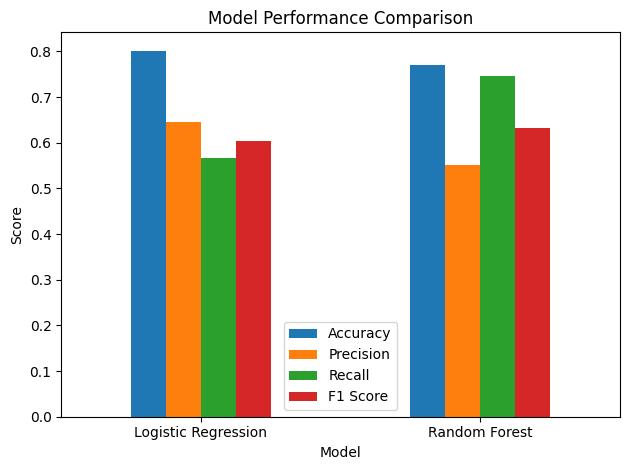

In [15]:
import matplotlib.pyplot as plt # Verilerimi görsel bir şölene dönüştürmek ve grafikler çizmek için bu kütüphaneyi çağırdım.

# Modellerin performans metriklerini (Accuracy, Precision, Recall, F1 Score) yan yana görebileceğim bir çubuk grafik (bar plot) oluşturdum.
comparison.plot(x="Model", y=["Accuracy", "Precision", "Recall", "F1 Score"], kind="bar")

# Grafiğimin neyi anlattığını netleştirmek için üst kısma "Model Performance Comparison" başlığını ekledim.
plt.title("Model Performance Comparison")

# Y ekseninin skor değerlerini (0 ile 1 arası) temsil ettiğini belirtmek için "Score" etiketini koydum.
plt.ylabel("Score")

# Model isimlerinin (Logistic Regression, Random Forest) grafiğin altında düzgün ve okunaklı durması için yazıların açısını 0 derece (yatay) yaptım.
plt.xticks(rotation=0)

# Grafik içindeki yazıların, başlıkların ve eksenlerin birbirine girmemesi, her şeyin derli toplu durması için bu düzenleme fonksiyonunu kullandım.
plt.tight_layout()

# Hazırladığım bu karşılaştırma görselini ekrana basarak analizimi görsel bir kanıtla taçlandırdım.
plt.show()

Churn tahmin problemlerinde, müşteri kaybını önlemek kritik olduğundan recall metriği accuracy’den daha öncelikli değerlendirilmelidir. Bu bağlamda Random Forest modeli, churn edecek müşterileri daha yüksek oranda tespit edebildiği için iş hedeflerine daha uygun bir model olarak değerlendirilebilir.

# Model Performans Karşılaştırma

### Genel Değerlendirme

Grafik incelendiğinde **Logistic Regression** ve **Random Forest** modellerinin performans metrikleri karşılaştırılmıştır. Her iki modelin farklı metriklerde farklı güçlü yönleri olduğu görülmektedir.

---

### Accuracy (Doğruluk)

* Logistic Regression: ~0.80
* Random Forest: ~0.77

Logistic Regression modeli genel doğruluk açısından biraz daha iyi performans göstermektedir.

Yorum:
Model genel olarak doğru tahmin yapma konusunda Logistic Regression daha başarılıdır.

---

### Precision (Kesinlik)

* Logistic Regression: ~0.65
* Random Forest: ~0.55

Logistic Regression daha yüksek precision değerine sahiptir.

Yorum:
Logistic Regression modeli, churn dediği müşterilerde daha az hata yapmaktadır.
Yani **yanlış alarm (False Positive)** oranı daha düşüktür.

---

### Recall (Yakalama Oranı)

* Logistic Regression: ~0.57
* Random Forest: ~0.75

Random Forest burada açık ara daha başarılıdır.

Yorum:
Random Forest modeli churn edecek müşterileri yakalama konusunda çok daha güçlüdür.

Bu metrik iş açısından en kritik olanıdır.

---

###  F1 Score

* Logistic Regression: ~0.60
* Random Forest: ~0.63

Random Forest biraz daha dengeli bir performans sunmaktadır.

Yorum:
Precision ve Recall dengesine bakıldığında Random Forest daha dengeli bir modeldir.




#EDA — Görselleştirme Dashboard (Seaborn)

Veri temizleme adımlarını tamamladım ve şimdi görselleştirme aşamasına geçmeden önce son hazırlıklarımı yapıyorum. Grafiklerin daha profesyonel ve okunaklı görünmesi için stil ayarlarını yapıp verimi stabilize ettim:

In [19]:
import pandas as pd # Veri manipülasyonu için ana aracımı kullanmaya devam ediyorum.
import seaborn as sns # Matplotlib üzerine kurulu, daha şık ve gelişmiş grafikler çizmemi sağlayan kütüphaneyi dahil ettim.
import matplotlib.pyplot as plt # Çizdiğim grafikleri özelleştirmek ve ekranda göstermek için bu kütüphaneyi kullanıyorum.

# Grafiklerin arka planında ince beyaz çizgiler (ızgara) olmasını sağlayarak okunabilirliği artırmak için bu stili seçtim.
sns.set_style("whitegrid")

# Analizlerimde hata almamak için 'TotalCharges' sütunundaki verileri sayısal formata zorladım.
# Eğer içinde sayıya çevrilemeyen hatalı karakterler varsa onları 'NaN' (geçersiz veri) olarak işaretledim.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Sayısal dönüşümden sonra ortaya çıkan veya veride zaten var olan tüm boş/eksik satırları tamamen temizledim.
# Bu sayede görselleştirme yaparken herhangi bir kesinti veya hata yaşamayacağım.
df.dropna(inplace=True)

Veriyi temizledikten sonra şimdi ilk görselleştirmemi yapıyorum. Amacım, elimdeki veri setinde dengeli bir dağılım olup olmadığını gözlerimle görmek. İşte bu görseli oluştururken attığım adımlar:

##Churn Dağılımı

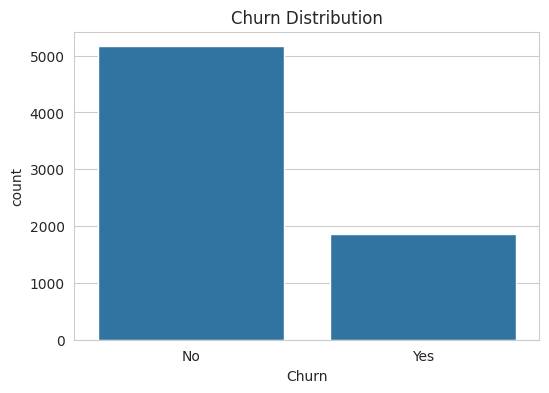

In [41]:
# Grafiğimin boyutlarını, çok büyük ya da küçük olup görüntüyü bozmaması için 6'ya 4 oranında ayarladım.
plt.figure(figsize=(6,4))

# Seaborn kütüphanesini kullanarak "Churn" sütunundaki sınıfların (Giden/Kalan) sayısal dağılımını gösteren bir sütun grafiği hazırladım.
sns.countplot(x="Churn", data=df)

# Grafiğin neyi temsil ettiği anlaşılsın diye üst kısma "Churn Distribution" başlığını yerleştirdim.
plt.title("Churn Distribution")

# Tüm ayarları tamamladıktan sonra hazırladığım bu grafiği ekranda görüntüledim.
plt.show()

Genel Değerlendirme

Grafik incelendiğinde veri setinde churn dağılımının dengesiz (imbalanced) olduğu açıkça görülmektedir.

Churn = No (müşteri kalmış) → ~5174
Churn = Yes (müşteri ayrılmış) → ~1869

Bu da yaklaşık olarak:

%73 → müşteri kalmış

##Churn vs Gender

Müşteri kaybının cinsiyete göre nasıl değiştiğini merak ettim ve veriyi bu açıdan incelemeye karar verdim. Erkek veya kadın müşterilerin hangisinin ayrılmaya daha meyilli olduğunu bu grafik sayesinde bir bakışta görebileceğim:

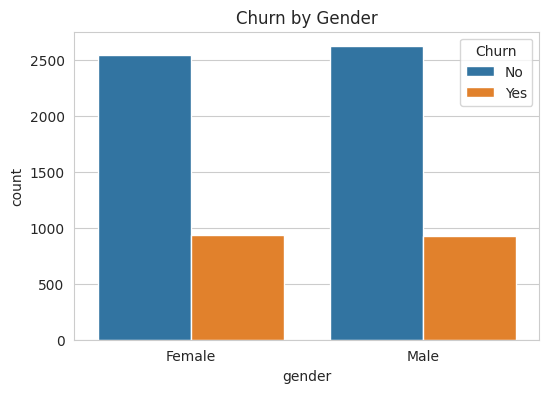

In [42]:
# Grafiğin çerçevesini, verilerin sıkışık görünmemesi için 6'ya 4 boyutlarında hazırladım.
plt.figure(figsize=(6,4))

# Seaborn ile cinsiyet bazlı bir sayım grafiği oluşturdum.
# 'hue="Churn"' parametresini kullanarak, her cinsiyet kategorisini kendi içinde "ayrılanlar" ve "kalanlar" olarak iki farklı renge böldüm.
sns.countplot(x="gender", hue="Churn", data=df)

# Grafiğin neyi incelediğini belirtmek için "Churn by Gender" (Cinsiyete Göre Müşteri Kaybı) başlığını ekledim.
plt.title("Churn by Gender")

# Hazırladığım görseli ekrana basarak, cinsiyetin müşteri kaybı üzerinde belirgin bir etkisi olup olmadığını analiz ettim.
plt.show()

Genel Değerlendirme

Grafik incelendiğinde kadın ve erkek müşteriler arasında churn davranışı karşılaştırılmıştır.

Kadın ve erkek müşteri sayıları birbirine oldukça yakındır
Her iki grupta da churn eden müşteri sayısı benzer seviyededir

Yorum : Cinsiyet dağılımı dengeli

##Churn vs Tenure

Müşterilerin bizimle ne kadar süredir çalıştığının (tenure) sadakatleri üzerinde nasıl bir etkisi olduğunu görmek istedim. Yeni müşteriler mi daha çabuk gidiyor yoksa eski dostlarımızı mı kaybediyoruz? İşte bu sorunun cevabını aradığım grafik adımları:

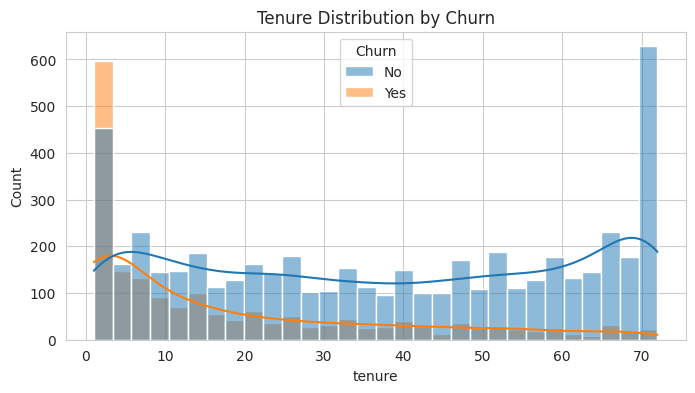

In [43]:
# Verilerin detaylarını daha rahat görebilmek için grafik alanını biraz daha genişletip 8'e 4 boyutlarına getirdim.
plt.figure(figsize=(8,4))

# Seaborn'un histplot fonksiyonuyla 'tenure' sütununun dağılımını çizdirdim.
# 'hue="Churn"' ile gidenleri ve kalanları farklı renklerle ayırdım.
# 'bins=30' diyerek veriyi 30 parçaya böldüm, 'kde=True' ile de yoğunluğu gösteren yumuşak bir çizgi ekledim.
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)

# Grafiğin üstüne, çalışma süresinin churn üzerindeki etkisini anlatan "Tenure Distribution by Churn" başlığını koydum.
plt.title("Tenure Distribution by Churn")

# Analizimi tamamlamak için bu detaylı dağılım grafiğini ekrana yansıttım.
plt.show()

Genel Değerlendirme

Grafik, müşterilerin sistemde kalma süresi (tenure) ile churn davranışı arasındaki ilişkiyi göstermektedir.

Yorum :
Düşük tenure (0–10 ay) → churn çok yüksek
Yüksek tenure (50+ ay) → churn çok düşük

##Churn vs Monthly Charges

Müşterilerin aylık ödediği ücretlerin (MonthlyCharges) onları bizden koparıp koparmadığına dair bir kanıt arıyorum. Bu yüzden, giden ve kalan müşterilerin ödediği tutarları kıyaslamak için en iyi yöntemlerden biri olan kutu grafiğini (box plot) kullanmaya karar verdim:

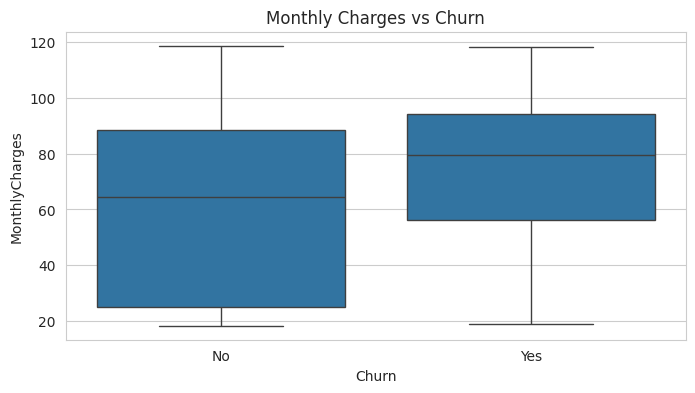

In [44]:
# Grafiğin daha okunaklı ve ferah olması için çerçeve boyutunu 8'e 4 olarak belirledim.
plt.figure(figsize=(8,4))

# Seaborn ile "Churn" durumuna göre "MonthlyCharges" (Aylık Ücret) dağılımını gösteren bir kutu grafiği çizdirdim.
# Bu grafik bana medyan değerleri, yayılımı ve olası uç değerleri (outliers) doğrudan gösterecek.
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

# Analizimin amacını belirten "Monthly Charges vs Churn" (Aylık Ücretler ve Churn Kıyaslaması) başlığını ekledim.
plt.title("Monthly Charges vs Churn")

# Hazırladığım bu karşılaştırmalı analizi ekrana yansıttım.
plt.show()

Genel Değerlendirme

Grafik incelendiğinde churn eden ve etmeyen müşterilerin aylık ücret dağılımları (MonthlyCharges) karşılaştırılmıştır.

Yorum :

Churn eden müşterilerin medyan aylık ücreti daha yüksek
Ücret arttıkça churn eğilimi artmaktadır

##Churn vs Contract Type

Müşteri kaybı analizinde belki de en kilit noktaya geldim: Sözleşme tipi. Müşterilerimizin ne kadar süreyle bize bağlı kalmayı taahhüt ettikleri, aslında gitme ihtimallerini doğrudan belirliyor. İşte bu bağı görmek için yaptığım çalışma:

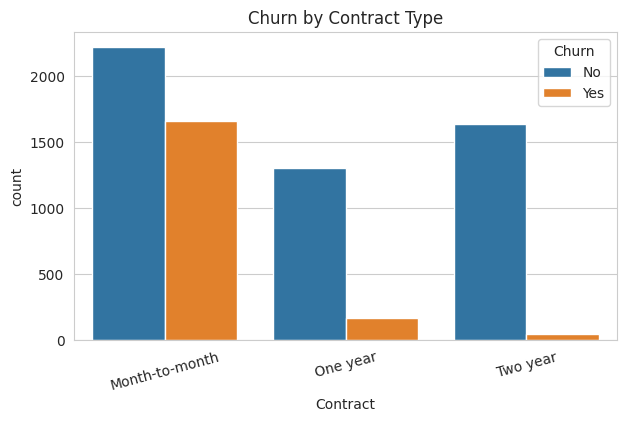

In [45]:
# Grafiğin hem kategori isimlerini hem de çubukları rahatça gösterebilmesi için boyutunu 7'ye 4 olarak ayarladım.
plt.figure(figsize=(7,4))

# Seaborn ile sözleşme türlerine (Contract) göre bir sayım grafiği oluşturdum.
# 'hue="Churn"' ekleyerek, her bir sözleşme tipinde (Aylık, 1 Yıllık, 2 Yıllık) giden ve kalanların oranını renklerle ayırdım.
sns.countplot(x="Contract", hue="Churn", data=df)

# Analizimin odak noktasını belirtmek için "Churn by Contract Type" başlığını ekledim.
plt.title("Churn by Contract Type")

# Sözleşme isimleri (Örn: Month-to-month) bazen uzun olup birbirine girebiliyor; bu yüzden yazıları 15 derece döndürerek daha okunaklı hale getirdim.
plt.xticks(rotation=15)

# Tüm hazırlıklarımı tamamlayıp sözleşme bağlılığının churn üzerindeki etkisini görmek için grafiği ekrana bastım.
plt.show()

Genel Değerlendirme

Grafik, müşterilerin kontrat tipine göre churn davranışını göstermektedir:

Month-to-month (Aylık)
One year (1 yıllık)
Two year (2 yıllık)

Yorum :

Kontrat süresi arttıkça churn dramatik şekilde azalıyor.

##Churn vs Payment Method

Müşteri sadakati ve ödeme yöntemleri arasındaki ilişkiyi de masaya yatırmak istedim. Ödeme sürecindeki bir pürüzün veya yöntemin kolaylığının, müşterinin bizde kalma kararını etkileyip etkilemediğini bu grafikle çözmeyi hedefliyorum:

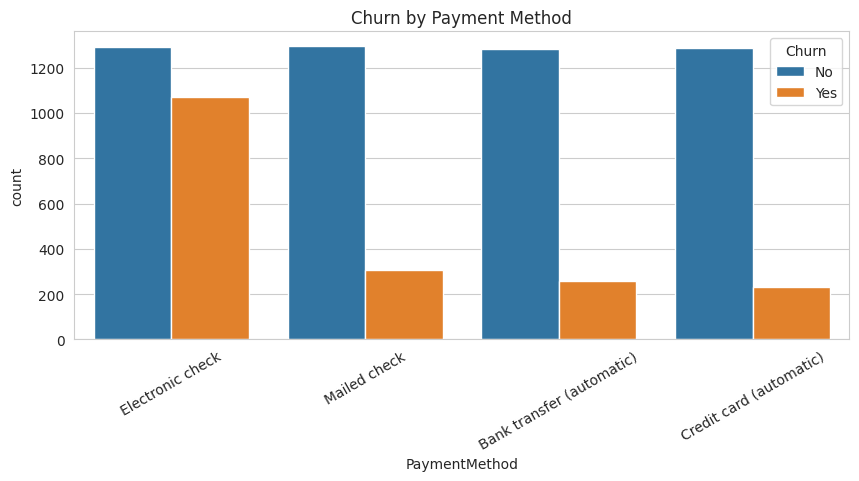

In [46]:
# Ödeme yöntemi isimleri uzun olduğu ve yan yana çok fazla kategori bulunduğu için genişliği 10'a çıkararak ferah bir alan oluşturdum.
plt.figure(figsize=(10,4))

# Seaborn kullanarak her bir ödeme yöntemi (PaymentMethod) bazında kaç müşterinin kaldığını veya gittiğini gösteren renkli çubuklar çizdirdim.
# 'hue="Churn"' ile ayrılanları (Yes) ve kalanları (No) görsel olarak birbirinden ayırdım.
sns.countplot(x="PaymentMethod", hue="Churn", data=df)

# Grafiğe analizimin amacını yansıtan "Churn by Payment Method" başlığını ekledim.
plt.title("Churn by Payment Method")

# "Electronic check" gibi uzun isimlerin birbirinin üzerine binmemesi ve rahatça okunabilmesi için alt yazıları 30 derece döndürdüm.
plt.xticks(rotation=30)

# Veriyi bir hikayeye dönüştüren bu son görseli ekranda görüntüledim.
plt.show()

Genel Değerlendirme

Grafik, müşterilerin kullandığı ödeme yöntemine göre churn davranışını göstermektedir:

Electronic check
Mailed check
Bank transfer (automatic)
Credit card (automatic)

Yorum :

Electronic check kullanan müşterilerde churn oranı belirgin şekilde daha yüksek

##Churn vs Internet Service

Müşteri kaybı analizimde son olarak internet hizmeti türüne odaklanıyorum. Fiber optik mi, DSL mi yoksa internet hizmeti almayanlar mı daha sadık? Bu sorunun cevabı, teknik altyapımızın müşteri memnuniyeti üzerindeki etkisini anlamamı sağlayacak:

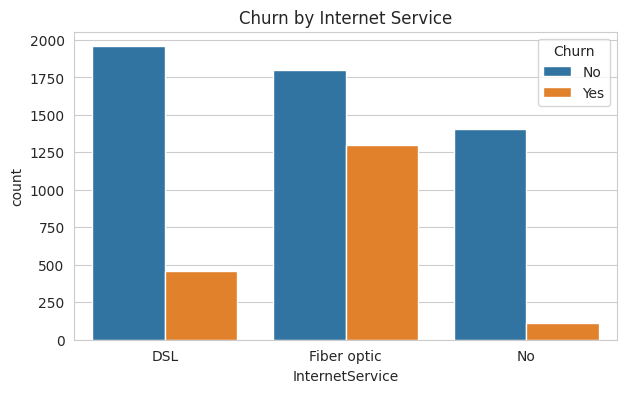

In [47]:
# Grafiğin dengeli ve okunabilir durması için çerçeve boyutunu 7'ye 4 olarak belirledim.
plt.figure(figsize=(7,4))

# Seaborn ile sunulan internet hizmeti türlerine (InternetService) göre bir sayım grafiği hazırladım.
# 'hue="Churn"' parametresiyle, her hizmet türündeki giden ve kalan müşterileri farklı renklerle gruplandırdım.
sns.countplot(x="InternetService", hue="Churn", data=df)

# Analizimin neyi temsil ettiğini belirten "Churn by Internet Service" başlığını ekledim.
plt.title("Churn by Internet Service")

# Hazırladığım bu stratejik görseli ekrana basarak, hizmet kalitesi ile müşteri kaybı arasındaki bağı inceledim.
plt.show()

Genel Değerlendirme

Grafik, müşterilerin kullandığı internet hizmet türüne göre churn davranışını göstermektedir:

DSL
Fiber optic
No internet service

Yorum:

Fiber optic kullanıcılarında churn oranı belirgin şekilde daha yüksek

##Korelasyon Heatmap

Analizimin en kapsamlı adımlarından birine geldim. Hangi değişkenlerin birbiriyle el ele tutuştuğunu, hangilerinin birbirinden tamamen bağımsız olduğunu anlamak için bir "ilişki haritası" çıkarıyorum. İşte bu ısı haritasını oluştururken izlediğim yol:

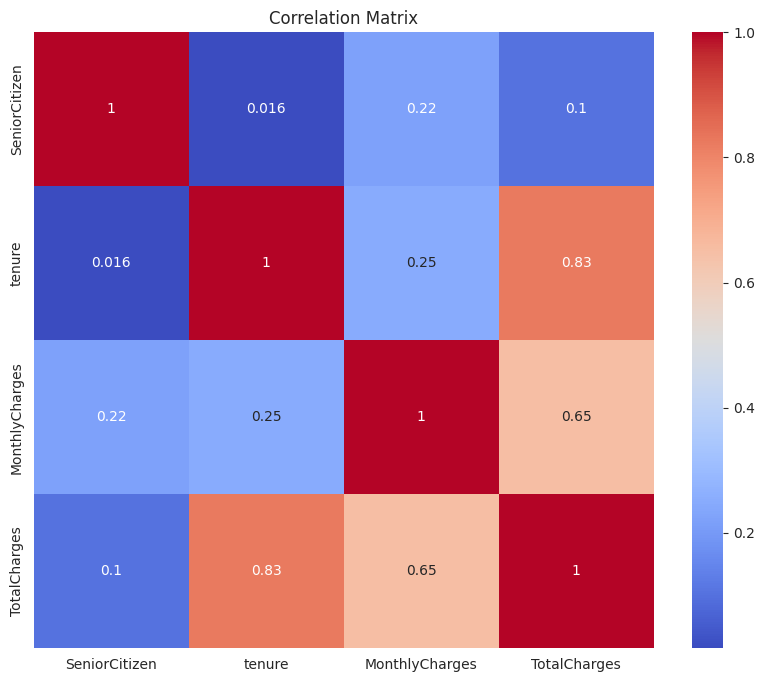

In [50]:
# Grafiğin içindeki sayıların ve kutucukların net okunabilmesi için oldukça geniş bir alan (10'a 8) ayırdım.
plt.figure(figsize=(10,8))

# Korelasyon analizi sadece sayılarla anlamlı olduğu için, veri setimdeki metin tabanlı sütunları eledim ve sadece sayısal olanları seçtim.
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Sayısal değişkenlerin birbirleriyle olan matematiksel bağını hesapladım;
# Seaborn ile bunu bir ısı haritasına (heatmap) dönüştürürken, her kutucuğa ilişki puanını yazdırdım (annot=True).
# Renk paleti olarak 'coolwarm' seçtim ki güçlü negatif ve pozitif ilişkiler renklerle hemen göze çarpsın.
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

# Grafiğin neyi temsil ettiğini belirtmek için "Correlation Matrix" (Korelasyon Matrisi) başlığını ekledim.
plt.title("Correlation Matrix")

# Tüm hesaplamaları ve görsel ayarları bitirdikten sonra bu renkli tabloyu ekrana bastım.
plt.show()

Genel Değerlendirme

Bu korelasyon matrisi, sayısal değişkenler arasındaki ilişkileri göstermektedir:

* SeniorCitizen
* tenure
* MonthlyCharges
* TotalCharges

Korelasyon değerleri -1 ile +1 arasında değişir:

* 0 → ilişki yok
* 1 → güçlü pozitif ilişki
* -1 → güçlü negatif ilişki

##Insight Grafiği

Analizimi daha derin bir boyuta taşıyorum. Sadece sözleşme tipine veya sadece süreye bakmak yerine, bu ikisinin birleşip "Churn" (terk) üzerinde nasıl bir fırtına kopardığını anlamaya çalışıyorum. Müşterinin ne kadar süredir bizimle olduğu ile seçtiği sözleşme arasındaki bağı şu adımlarla görselleştirdim:

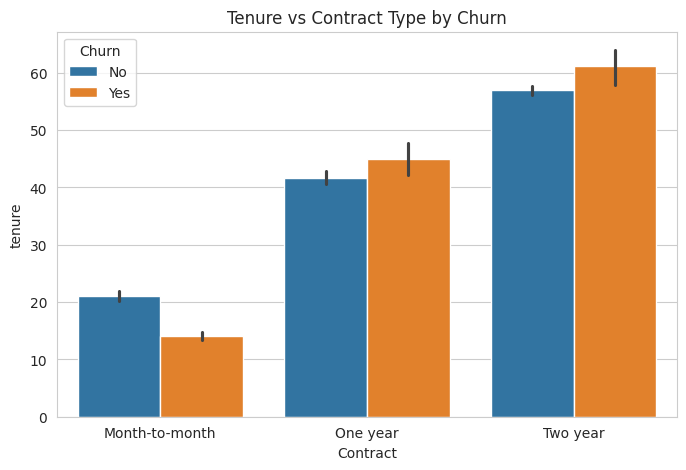

In [51]:
# Grafiğin hem çubukları hem de lejantı (açıklama kısmını) ferah bir şekilde gösterebilmesi için 8'e 5 boyutlarını belirledim.
plt.figure(figsize=(8,5))

# Seaborn ile bir bar grafiği oluşturdum.
# X eksenine sözleşme tipini, Y eksenine ise müşterinin ne kadar süredir (tenure) bizimle olduğunu koydum.
# 'hue="Churn"' ekleyerek, her sözleşme grubunda kalanlar ve gidenlerin ortalama sürelerini kıyasladım.
sns.barplot(x="Contract", y="tenure", hue="Churn", data=df)

# Grafiğe analizimin kapsamını özetleyen "Tenure vs Contract Type by Churn" başlığını ekledim.
plt.title("Tenure vs Contract Type by Churn")

# Tüm ayarlar bittikten sonra, sözleşme sadakati ve süre ilişkisini gösteren bu anlamlı tabloyu ekrana yansıttım.
plt.show()

Genel Değerlendirme

Bu grafik, müşterilerin:

kontrat tipi
sistemde kalma süresi (tenure)
churn durumu

arasındaki ilişkiyi birlikte göstermektedir.

Yani artık şuna bakıyoruz:
“Hangi kontrat + hangi müşteri süresi = churn?”

1. Month-to-month → En riskli segment
Churn edenlerin tenure’ı düşük (~14)
Kalanların tenure’ı biraz daha yüksek (~21)

Yorum:  Aylık müşteriler zaten kısa süreli ve hızlı şekilde churn ediyor

En riskli grup: kısa tenure + aylık kontrat

2. One year → Orta risk
Churn edenler: ~45 tenure
Kalanlar: ~42 tenure

İlginç nokta: Churn eden müşteriler bile uzun süre kalmış

Yorum: Bu müşteriler sonradan memnuniyetsizlik yaşamış olabilir

3. Two year → En stabil segment
Her iki grupta da tenure çok yüksek (~60+)
Churn neredeyse yok

Yorum: Uzun kontrat = yüksek bağlılık

Churn sadece tenure ile değil, tenure + contract birlikte değerlendirilmelidir.Churn davranışı yalnızca tek bir değişkenle açıklanamaz. Tenure ve contract değişkenlerinin birlikte incelenmesi, özellikle kısa süreli ve aylık kontrata sahip müşterilerin en yüksek churn riskine sahip olduğunu göstermektedir. Bu durum, müşteri yaşam döngüsünün erken aşamalarında yapılacak iyileştirmelerin kritik olduğunu ortaya koymaktadır.




#Confusion Matrix Görselleştirme (Seaborn)

##Logistic Regression Confusion Matrix

Analizimin en can alıcı performans raporlarından birini daha şık ve anlaşılır bir hale getiriyorum. Sayıların içinde kaybolmak yerine, modelimin yaptığı doğru ve yanlış tahminleri bir "ısı haritası" üzerinde, nerede yoğunlaştıklarını görerek analiz ediyorum:

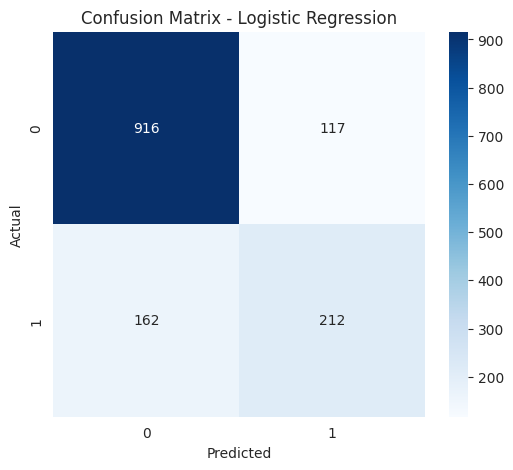

In [52]:
import seaborn as sns # Hata matrisini görsel olarak daha etkileyici kılmak için Seaborn kütüphanesinden yararlandım.
import matplotlib.pyplot as plt # Grafiğin iskeletini oluşturmak ve ekrana basmak için bu kütüphaneyi kullandım.
from sklearn.metrics import confusion_matrix # Modelimin gerçek performansını ölçen hata matrisi fonksiyonunu çağırdım.

# Modelimin test verileri üzerindeki tahminleri ile gerçek sonuçları karşılaştıran temel matrisi hesapladım.
cm = confusion_matrix(y_test, y_pred)

# Grafiğin kutucuklarının ve sayıların net okunabilmesi için 6'ya 5 boyutlarında bir çerçeve hazırladım.
plt.figure(figsize=(6,5))

# Seaborn ile bu matrisi bir ısı haritasına dönüştürdüm.
# 'annot=True' ile kutuların içine sayıları yazdırdım, 'fmt="d"' ile bu sayıların tam sayı (ondalıksız) olmasını sağladım.
# 'cmap="Blues"' tercih ederek başarının yoğunlaştığı yerlerin koyu maviyle parlamasını istedim.
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# Grafiğin hangi modele ait olduğunu belirten "Confusion Matrix - Logistic Regression" başlığını ekledim.
plt.title("Confusion Matrix - Logistic Regression")

# X eksenine modelimin verdiği kararları (Predicted), Y eksenine ise gerçek durumu (Actual) temsil eden etiketleri koydum.
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Hazırladığım bu hata tablosunu ekrana yansıtarak kaç kişiyi doğru, kaç kişiyi yanlış tahmin ettiğimi görsel olarak inceledim.
plt.show()


###  Genel Değerlendirme

|                | Predicted: No | Predicted: Yes |
| -------------- | ------------- | -------------- |
| **Actual No**  | 916 (TN)      | 117 (FP)       |
| **Actual Yes** | 162 (FN)      | 212 (TP)       |

---

#  Detaylı Analiz

##  1. True Negatives (916)

Model:

* Kalacak müşterileri doğru tahmin etmiş
* En büyük grup burada

Yorum:
Model “stabil müşterileri” iyi yakalıyor

---

##  2. True Positives (212)

Model:

* Churn edecek müşterileri doğru yakalamış

Yorum:
Bu iyi ama daha yüksek olmalıydı

---

##  3. False Positives (117)

Model:

* Kalacak müşterilere “gidecek” demiş

Yorum:

* Gereksiz aksiyon alınabilir
* Ama business için çok kritik değil

---

## 4. False Negatives (162) → EN KRİTİK

Model:

* Gidecek müşterileri KAÇIRMIŞ

 Yorum:
**Şirketin para kaybettiği yer burası**

---

# En Kritik Insight

Model churn müşterilerin bir kısmını kaçırıyor

---

# Basit metrik hesaplayalım

Recall (Churn yakalama oranı):


Recall = {TP}\{TP + FN} = {212}\{212 + 162} ≈ 0.57


Yani:
**Model churn müşterilerin sadece %57’sini yakalıyor**

Bu ne demek?

* %43 churn müşteri KAÇIRILIYOR 🚨
* Bu müşterilere hiçbir aksiyon alınmıyor



# Yorum

Logistic Regression modeli genel doğruluk açısından iyi performans göstermesine rağmen, churn edecek müşterilerin önemli bir kısmını kaçırmaktadır. Özellikle False Negative değerlerinin yüksek olması, modelin müşteri kaybını önleme açısından sınırlı kaldığını göstermektedir. Churn problemlerinde False Negative hataları, False Positive hatalara kıyasla daha kritik olup doğrudan müşteri kaybına yol açmaktadır. Bu nedenle model değerlendirmesinde recall metriğinin öncelikli olarak optimize edilmesi gerekmektedir.

---

#  İyileştirme Önerisi

Bu modeli nasıl iyileştiririz?

### Threshold düşür

```python
threshold = 0.3
```

Daha fazla churn yakalarsın

# Kısa Net Sonuç

Model iyi ama eksik
En büyük sorun: churn kaçırma
Amaç: recall artırmak


##Random Forest Confusion Matrix

Lojistik Regresyon’dan sonra şimdi de Random Forest modelimin hata matrisini görselleştiriyorum. Bakalım bu "orman" modeli, hataları azaltma konusunda ne kadar başarılı olmuş? İşte bu görsel analizi yaptığım adımlar:

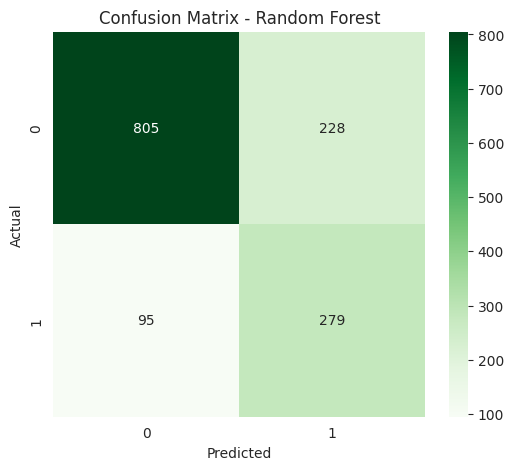

In [53]:
# Random Forest modelimin test setindeki gerçek değerler ile tahminlerini kıyaslayan hata matrisini hesapladım.
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Grafiğin kutucuklarının ferah görünmesi ve sayıların rahat okunması için 6'ya 5 boyutunda bir alan ayırdım.
plt.figure(figsize=(6,5))

# Seaborn ile bu matrisi bir ısı haritasına dönüştürdüm.
# 'annot=True' ile kutuların içine tahmin sayılarını yazdırdım, 'fmt="d"' ile bunların tam sayı olarak kalmasını sağladım.
# Lojistik Regresyon'dan ayırt edebilmek için bu sefer 'cmap="Greens"' (Yeşil tonları) paletini tercih ettim.
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")

# Grafiğe hangi modele ait olduğunu belirten "Confusion Matrix - Random Forest" başlığını ekledim.
plt.title("Confusion Matrix - Random Forest")

# Yatay eksene modelimin tahminlerini (Predicted), dikey eksene ise müşterilerin gerçek durumlarını (Actual) yazdım.
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Hazırladığım bu yeşil tonlu hata tablosunu ekrana yansıtarak tahminlerimin isabet oranını inceledim.
plt.show()


### Genel Değerlendirme

|                | Predicted: No | Predicted: Yes |
| -------------- | ------------- | -------------- |
| **Actual No**  | 805 (TN)      | 228 (FP)       |
| **Actual Yes** | 95 (FN)       | 279 (TP)       |

---

# Detaylı Analiz

## 1. True Positives (279) → ÇOK İYİ

Model:

* Churn edecek müşterileri daha fazla yakalamış

Logistic Regression’a göre:

* 212 → 279 (artış)

---

## 2. False Negatives (95) → ÇOK AZALDI

 Model:

* Kaçırılan churn müşteri sayısı düştü

 Logistic Regression:

* 162 → 95 (çok ciddi iyileşme)

---

##  3. False Positives (228) → ARTTI

 Model:

* Daha fazla “yanlış alarm” veriyor

Logistic Regression:

* 117 → 228

---

##  4. True Negatives (805)

Model:

* Stabil müşterileri biraz daha az doğru yakalamış
  (916 → 805)

---

## Recall

Logistic Regression: Recall ≈ 0.57


Random Forest: Recall ={279}/{279 + 95} ≈ 0.75


**%57 → %75 (MUAZZAM ARTIŞ)**

---

### Logistic Regression:

* Daha az yanlış alarm
* Ama çok müşteri kaçırıyor

### Random Forest:

* Daha fazla yanlış alarm
* Ama churn müşteriyi YAKALIYOR

---

# En Kritik Karar

Bu projede doğru model:

#**Random Forest**

---

Random Forest modeli, Logistic Regression modeline kıyasla churn edecek müşterileri daha yüksek oranda tespit edebilmiştir. False Negative değerlerinin önemli ölçüde azalması, modelin müşteri kaybını önleme açısından daha etkili olduğunu göstermektedir.

---
 Churn tahmin problemlerinde False Negative hataları, doğrudan müşteri kaybına yol açtığı için kritik öneme sahiptir. Random Forest modeli, bu hataları azaltarak daha yüksek recall değeri sunmuş ve iş hedefleri açısından daha uygun bir model olarak değerlendirilmiştir.

---

#  Trade-off (çok önemli kavram)

Ne oldu burada?

| Model         | FN (kaçırılan müşteri) | FP (yanlış alarm) |
| ------------- | ---------------------- | ----------------- |
| Logistic      | 162 ❌                  | 117 ✅             |
| Random Forest | 95 ✅                   | 228 ❌             |

Yani:

* Daha az müşteri kaçırdık ✅
* Ama daha fazla kişiye yanlış alarm verdik ❌

---

# Kısa Net Sonuç

Random Forest:

* daha agresif
* daha akıllı
* daha business odaklı

Logistic Regression:

* daha konservatif
* daha güvenli ama eksik
